In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load test data

For this demonstration, we will use the data found in `multimodal_data.csv` which contains real data from a clinical sample. Identifying information and outcomes have been removed, and the speech and actigraphy data has already been standardized. This notebook is just intended to show the methodological approach for classifying extreme psychomotor rhythm using the multimodal features.

In [2]:
df = pd.read_csv("test_data/multimodal_data.csv")
df

,speech_feature_1,speech_feature_2,speech_feature_3,speech_feature_4,actigraphy_feature_1,actigraphy_feature_2,actigraphy_feature_3,actigraphy_feature_4
0,-0.374198,0.855818,-0.701594,-0.460723,NaN,NaN,NaN,NaN
1,0.176872,0.319263,-0.872279,-1.500352,-0.327761,0.902930,0.143835,2.259599
2,-1.751872,0.723451,-0.189537,1.569345,-0.382789,-0.093909,0.143835,0.036987
3,0.511450,0.724033,-0.189537,-0.148804,NaN,NaN,NaN,NaN
4,-1.161440,-0.418296,0.166058,0.415390,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
205,1.298692,0.873055,0.130498,-0.475976,0.479320,3.362681,-2.580302,0.675328
206,0.609855,0.234666,-0.786937,-0.347626,-0.602902,0.428293,-1.207031,-0.430354
207,0.741062,-0.115166,-0.474013,-0.144085,2.515364,1.343191,1.452488,0.944206
208,0.167031,-0.319949,-0.829608,-0.334937,NaN,NaN,NaN,NaN


# Reducing collinearity

First, we will look for strong collinearity between the existing variables.

In [3]:
corr = df.corr(method="spearman")
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr[mask] = np.nan
corr.style.background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1).highlight_null(color='#f1f1f1').format(precision=2)

,speech_feature_1,speech_feature_2,speech_feature_3,speech_feature_4,actigraphy_feature_1,actigraphy_feature_2,actigraphy_feature_3,actigraphy_feature_4
speech_feature_1,nan,nan,nan,nan,nan,nan,nan,nan
speech_feature_2,-0.01,nan,nan,nan,nan,nan,nan,nan
speech_feature_3,-0.44,-0.03,nan,nan,nan,nan,nan,nan
speech_feature_4,-0.40,-0.10,0.33,nan,nan,nan,nan,nan
actigraphy_feature_1,-0.09,0.00,0.07,-0.07,nan,nan,nan,nan
actigraphy_feature_2,0.03,0.04,0.02,-0.05,0.59,nan,nan,nan
actigraphy_feature_3,-0.04,0.07,0.04,0.09,0.12,0.07,nan,nan
actigraphy_feature_4,-0.02,0.02,-0.01,0.05,-0.31,-0.26,0.01,nan


Based on the correlation matrix, we can see that among the speech features, `speech_feature_1` is notably correlated with other speech variables. Similarly, in the actigraphy features, `actigraphy_feature_1` shows signs of collinearity. Before proceeding, we will omit these features, as they would bias the method for counting extreme features.

In [ ]:
df = df.drop(columns=["speech_feature_1", "actigraphy_feature_1"], axis=1)

# Measuring extreme psychomotor rhythm

For each feature, we set a threshold such that the inner 80% of the distribution for that feature is considered to be a moderate value, and the outer 20% is considered to be an extreme value. Within each modality, we measure the overall degree of extremeness by counting the number of extreme-valued features.

In [ ]:
# Speech thresholding
speech_cols = [c for c in df.columns if "speech" in c]
lower_speech = df[speech_cols].quantile(0.10)
upper_speech = df[speech_cols].quantile(0.90)
extreme_speech = (df[speech_cols].lt(lower_speech)) | (df[speech_cols].gt(upper_speech))
df["speech_extreme_count"] = extreme_speech.sum(axis=1)

# Actigraphy thresholding
actigraphy_cols = [c for c in df.columns if "actigraphy" in c]
lower_actigraphy = df[actigraphy_cols].quantile(0.10)
upper_actigraphy = df[actigraphy_cols].quantile(0.90)
extreme_actigraphy = (df[actigraphy_cols].lt(lower_actigraphy)) | (df[actigraphy_cols].gt(upper_actigraphy))
df["actigraphy_extreme_count"] = extreme_actigraphy.sum(axis=1)

These charts show the number of individuals who fall under each total count of extreme-valued features.

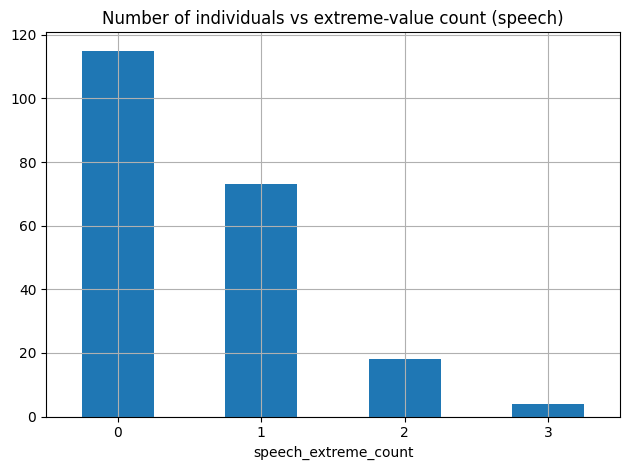

In [9]:
df["speech_extreme_count"].value_counts().plot(kind="bar", rot=0)
plt.title("Number of individuals by extreme-value count (speech)")
plt.grid()
plt.tight_layout()
plt.show()

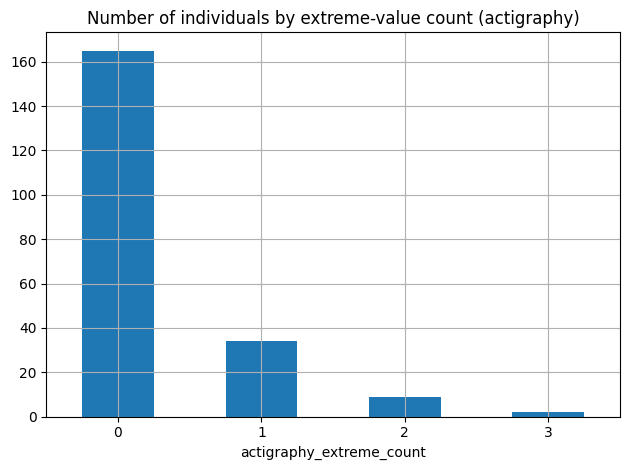

In [10]:
df["actigraphy_extreme_count"].value_counts().plot(kind="bar", rot=0)
plt.title("Number of individuals by extreme-value count (actigraphy)")
plt.grid()
plt.tight_layout()
plt.show()

In our analyses, we operated under the assumption that an extreme-value approach will likely only identify a small predictive grouping of individuals. In addition, we did not have complete data across the two modalities. Keeping these in mind, to combine speech and actigraphy we settled on the following multimodal indicator:

$$
\texttt{extreme\_psychomotor\_rhythm} = \begin{cases}
    1, & \text{if } \texttt{speech\_extreme\_count} >= 2 \quad \text{OR} \quad \texttt{actigraphy\_extreme\_count} >= 2 \\
    0, & \text{otherwise}
\end{cases}
$$

In [11]:
df["extreme_psychomotor_rhythm"] = (df["speech_extreme_count"] >= 2) | (df["actigraphy_extreme_count"] >= 2)

This identifies $31$ out of $210$ individuals in our sample. This binary classification can then be used as a predictor in a downstream analysis.

In [12]:
display(df[df["extreme_psychomotor_rhythm"] == 1])
print("Total individuals in extreme group:", df["extreme_psychomotor_rhythm"].sum())

,speech_feature_2,speech_feature_3,speech_feature_4,actigraphy_feature_2,actigraphy_feature_3,actigraphy_feature_4,speech_extreme_count,actigraphy_extreme_count,extreme_psychomotor_rhythm
1,0.319263,-0.872279,-1.500352,0.902930,0.143835,2.259599,2,1,True
17,0.191601,-0.189537,-0.051762,3.089395,-0.281181,2.270367,0,2,True
27,1.305661,-0.474013,-1.733987,NaN,NaN,NaN,2,0,True
41,-0.307951,-0.456233,-1.483441,1.712393,-0.578179,1.331637,1,2,True
44,1.356194,0.450534,-1.383119,NaN,NaN,NaN,2,0,True
45,-1.746299,0.578548,1.497922,NaN,NaN,NaN,2,0,True
49,-3.304612,5.037708,0.604526,0.500959,-0.230065,0.086222,2,0,True
54,-3.703153,5.784457,2.064877,-0.427203,-0.578179,0.764666,3,0,True
58,0.161132,0.166058,0.918375,-1.856984,0.981373,-1.218326,0,2,True
63,-5.933313,7.405969,1.447995,-0.804674,-0.903086,1.142172,3,0,True


Total individuals in extreme group: 31
